# Статистика, DS-поток
## Блиц-домашка SB.1

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Баллы за задание:**

* Задача 1 &mdash; 50 баллов
* Задача 2 &mdash; 20 баллов

**Важность задач:**

* *средне-высокая:* задача 1.
* *обычная* задача 2.

Степень важности задач не связана с количеством баллов и определяется только на основе оценки полезности задачи с точки зрения усвоения текущего и дальнейшего материала. Например, если вы что-то не успеваете, рекомендуется в первую очередь выполнять более важные задачи.

In [1]:
# Bot check

# HW_ID: ds_sb1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette='Set2')

---
### Задача 1.

Реализуйте метод Монте-Карло и метод прямоугольников численного интегрирования функций, используя приведенный ниже шаблон. Реализация должна уметь оценивать интегралы вида
$$ \int\limits_{\ell_1}^{h_1} ... \int\limits_{\ell_d}^{h_d} f(x_1, ... , x_d)\ dx_1 ... dx_d $$
для произвольной заданной функции $f$.

Реализация получает на вход векторы $\ell = (\ell_1, ... , \ell_d)$ и $h = (h_1, ... ,h_d)$, а также число $n$ &mdash; количество итераций оценки интеграла. В случае метода прямоугольников число итераций равно количеству используемых прямоугольников, а в случае метода Монте-Карло &mdash; размеру генерируемой выборки. 

*Требования:*
1. Значение функции $f$ можно посчитать только в $n$ точках.
2. Реализация не должна использовать какие-либо циклы, кроме циклов по числу интегралов $d$.
3. Для ускорения вычислений генерацию случайных чисел стоит производить с помощью `numpy.random`.
4. При реализации метода прямоугольников используйте равномерное разбиение по каждой координатной оси.

*Подсказка:* при реализации метода Монте-Карло обрати внимание на один из примеров с лекции.

Для быстрой работы метода прямоугольников используйте функцию <a href="https://docs.scipy.org/doc/numpy/reference/generated/numpy.meshgrid.html">`numpy.meshgrid`</a>. Ниже есть пример ее использования. 

In [2]:
# Предположим, мы хотим получить координаты всех целых точек (x, y), 
# таких, что x лежит в промежутке [5, 6], а y - в промежутке [-3, -1]

linspace_x = [5, 6, 7]  
linspace_y = [-3, -2, -1]

# возвращает матрицы с координатами сетки,
# задаваемой проекциями точек на оси координат
X, Y = np.meshgrid(linspace_x, linspace_y)

print("X: ", X)  # linspace_x повторилась len(linspace_y) раз по оси 0
print("Y: ", Y)  # linspace_y повторилась len(linspace_x) раз по оси 1
print(X.shape)
print(Y.shape)

# преобразуем исходный формат к вектору точек
np.stack([X, Y]).reshape(2, -1).T

X:  [[5 6 7]
 [5 6 7]
 [5 6 7]]
Y:  [[-3 -3 -3]
 [-2 -2 -2]
 [-1 -1 -1]]
(3, 3)
(3, 3)


array([[ 5, -3],
       [ 6, -3],
       [ 7, -3],
       [ 5, -2],
       [ 6, -2],
       [ 7, -2],
       [ 5, -1],
       [ 6, -1],
       [ 7, -1]])

In [19]:
class Integrator:
    
    @staticmethod
    def integrate(func, low, high, n_iter, method="rectangle"):
        """
        Оценка определенного интеграла.
        
        Аргументы:
        f --- векторная функция d-мерной переменной.
            Реализация функции на вход принимает матрицу (n, d),
            где n - число точек, в которых нужно вычислить функцию,
            а d - размерность пространства переменных.
            Функция должна вернуть вектор размерности n.
        low, high --- нижние и верхние пределы интегрирования,
            векторы размера d. Передаются в том же порядке,
            в котором функция принимает аргументы.
        n --- максимальное число вызовов функции f.
        method --- метод ("rectangle" или "monte_carlo").
                            
        Возвращает приближенное значение интеграла.
        """
        
        assert len(low) == len(high)
        low, high = map(np.array, [low, high])
        n_iter = int(n_iter)

        return Integrator.methods[method](func, low, high, n_iter)
    
    
    def integrate_monte_carlo(func, low, high, n_iter):
        """Метод монте-карло"""

        l = high - low
        V = np.prod(l)
        X = np.random.random(size=(n_iter, len(l))) * l + low
        
        return V * 1 / n_iter * np.sum(func(X))
    
    def integrate_rectangle(func, low, high, n_iter):
        """Метод прямоугольников"""
    
        n_axis = int(np.floor(np.power(n_iter, (1/d))))
        l = (high - low) / (n_axis)
        V = np.prod(l)
        dots = np.stack(np.meshgrid(*np.linspace(low + l / 2, high - l / 2, n_axis).T)).reshape(len(l), -1).T
        
        return np.sum(func(dots)) * V
    
    methods = {
        "rectangle": integrate_rectangle,
        "monte_carlo": integrate_monte_carlo
    }

Исследуем работу реализованных методов по оценке интеграла
$$\int\limits_0^1 ... \int\limits_0^1 \sum_{i=1}^{d} x_i^2 \prod_{i=1}^{d}dx_i,$$
то есть интегралы вида $\int\limits_0^1 x_1^2\ dx_1$, $\int\limits_0^1 \int\limits_0^1 \left( x_1^2 + x_2^2 \right)\ dx_1 dx_2$ и так далее.

Посчитайте точное значение этого интеграла в зависимости от $d$ теоретически.

$\int\limits_0^1 ... \int\limits_0^1 \sum_{i=1}^{d} x_i^2 \prod_{i=1}^{d}dx_i = d / 3$

In [20]:
n_iter = 1000
d = 2
low = np.zeros(d)
high = np.ones(d)

def func(X):
    return np.sum(np.power(X, 2), axis=1)

print(f'Теоретическое значение: {d / 3}')
print(f'Значение методом Монте-Карло: {Integrator.integrate_monte_carlo(func, low, high, n_iter)}')
print(f'Значение методом прямоугольников: {Integrator.integrate_rectangle(func, low, high, n_iter)}')

Теоретическое значение: 0.6666666666666666
Значение методом Монте-Карло: 0.6561727114294629
Значение методом прямоугольников: 0.6664932362122789


Вычислите $\int\limits_0^1 \int\limits_0^1 \left(x^2 + y^2\right)\ dxdy$ на миллионе запусков функции $f(x, y) = x^2+y^2$ двумя рассмотренными методами. Измерьте время работы методов и сравните результат с истинными значением интеграла. Различается ли время работы методов? Объясните результаты с точки зрения теории.

In [21]:
from time import perf_counter
from tqdm.notebook import tqdm

mk_results = []
rect_results = []
n = 1_000_00

n_iter = 1000
d = 2
low = np.zeros(d)
high = np.ones(d)

t0_mk = perf_counter()

for i in tqdm(range(n)):
    mk_results.append(Integrator.integrate_monte_carlo(func, low, high, n_iter))

t1_mk = perf_counter()

t0_rect = perf_counter()

for i in tqdm(range(n)):
    rect_results.append(Integrator.integrate_rectangle(func, low, high, n_iter))

t1_rect = perf_counter()

print(f'Время выполнения Монте-Карло: {t1_mk - t0_mk} с')
print(f'Среднее значение интеграла (МК): {np.mean(mk_results)}')

print(f'Время выполнения прямоугольников: {t1_rect - t0_rect} с')
print(f'Среднее значение интеграла (прям.): {np.mean(rect_results)}')

print(f'Теоретическое значение: {d / 3}')

  0%|          | 0/100000 [00:00<?, ?it/s]

  0%|          | 0/100000 [00:00<?, ?it/s]

Время выполнения Монте-Карло: 11.067671700002393 с
Среднее значение интеграла (МК): 0.6666629477874421
Время выполнения прямоугольников: 14.77770629999577 с
Среднее значение интеграла (прям.): 0.666493236212279
Теоретическое значение: 0.6666666666666666


Дольше работает метод прямоугольников, а ещё и менее точно. Наверно стоит начать увеличивать n_iter, и тогда прямоугльники начнут сходиться быстрее, потому что у Монте-Карло сходимость порядка $1/\sqrt n$, а у прямоугольников $1/n^2$.

Сравним скорость сходимости методов семпирования для $d = 1...8$. Для этого для каждого $d$ постройте график зависимости оценки двумя методами значения интеграла от количества итераций $n$. Рекомендуется рассмотреть значения $n$ вплоть до $d \times 1000$.

Аналогично сравните время работы методов.

In [ ]:
# d_grid = np.arange(1, 9)

# for d in d_grid:
#     mk_res = []
#     rect_res = []
    
#     n_grid = np.arange(100, d * 1000, 100)
#     low = np.zeros(d)
#     high = np.ones(d)
#     real_val = d / 3

#     for n in n_grid:
#         mk_res.append(Integrator.integrate_monte_carlo(func, low, high, n))
#         rect_res.append(Integrator.integrate_rectangle(func, low, high, n))

#     plt.figure(figsize=(8, 6))
#     plt.plot(n_grid, mk_res, color='c')
#     plt.plot(n_grid, rect_res, color='b')
#     plt.axhline(real_val, color='r', alpha=0.4)
#     plt.show()

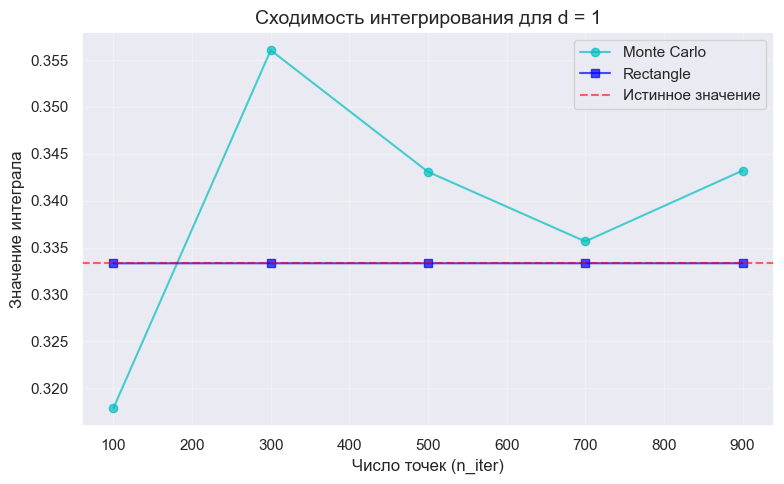

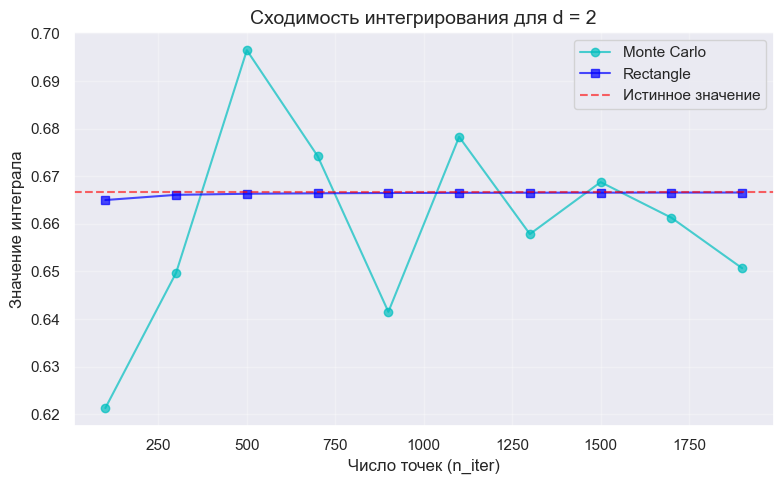

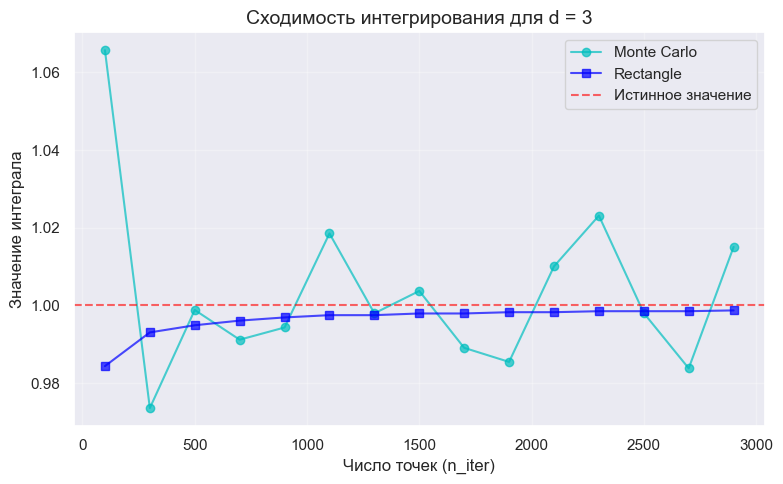

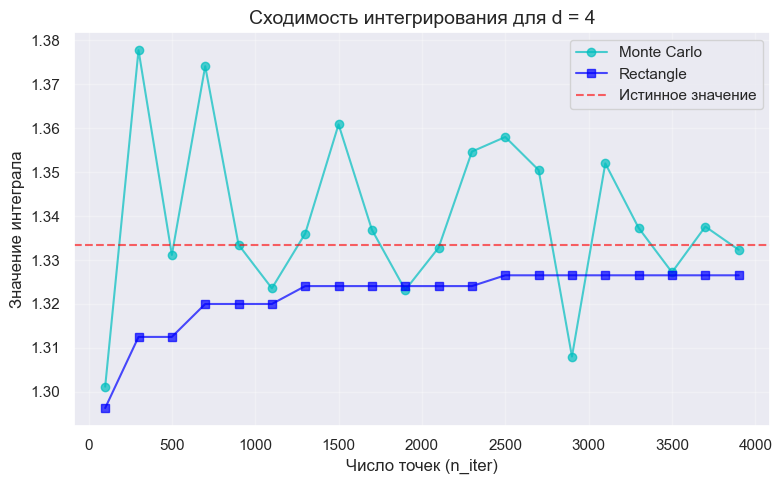

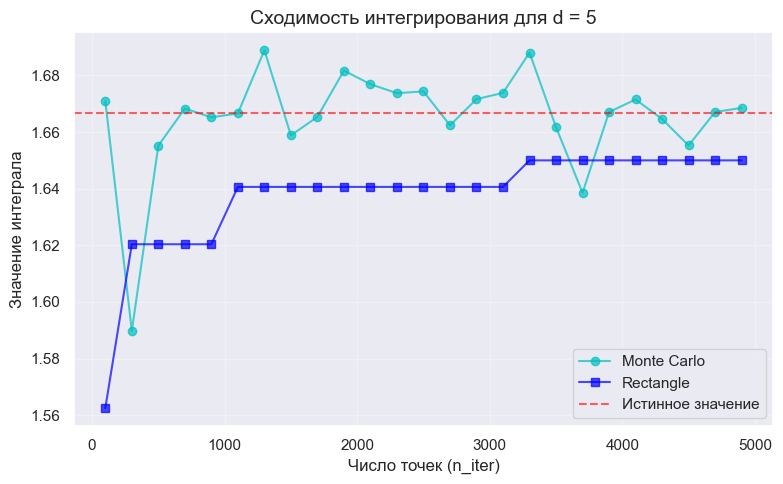

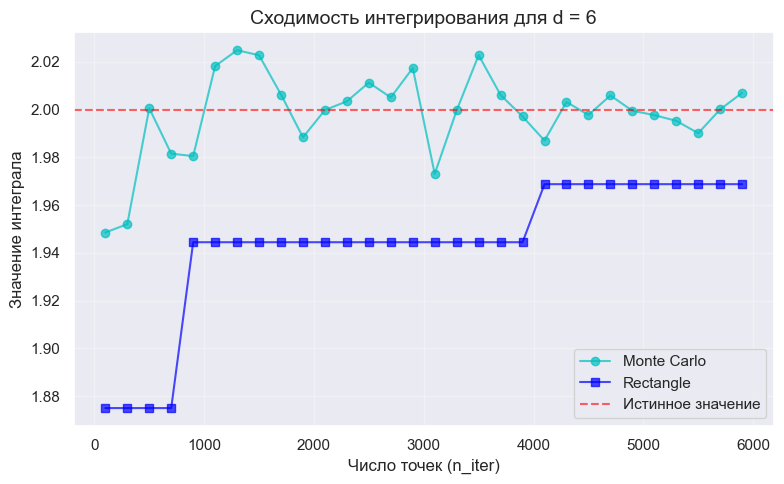

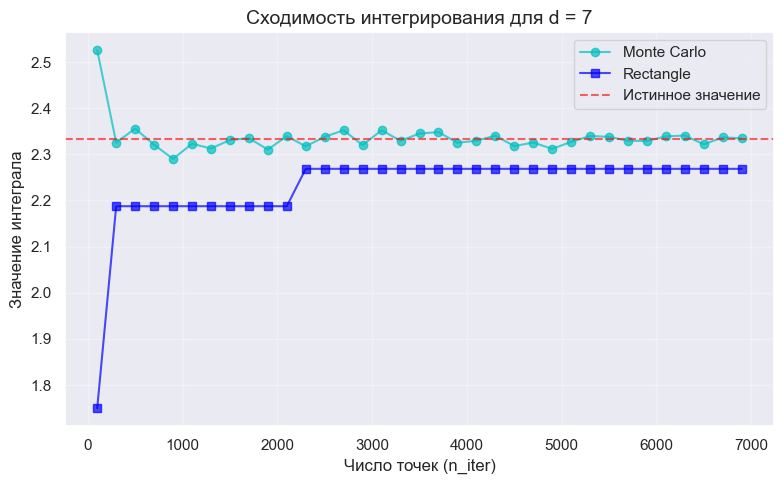

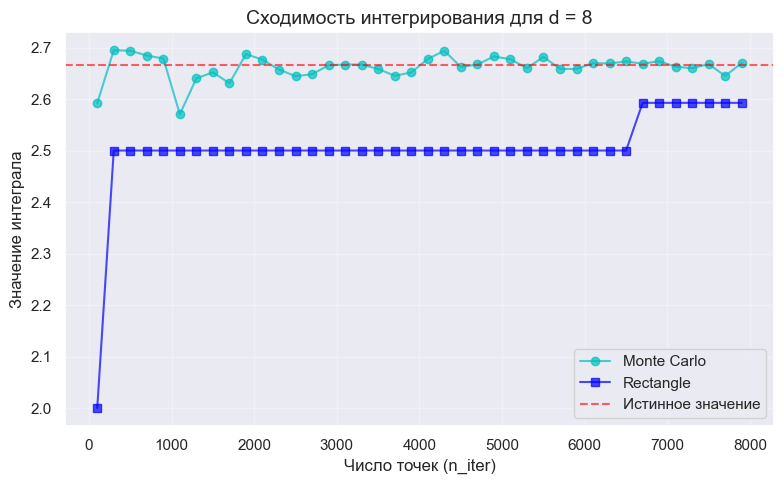

In [35]:
d_grid = np.arange(1, 9)

for d in d_grid:
    mk_res = []
    rect_res = []

    n_grid = np.arange(100, d * 1000, 200)  # шаг чуть крупнее, чтобы точек не было слишком много
    low = np.zeros(d)
    high = np.ones(d)
    real_val = d / 3

    for n in n_grid:
        mk_res.append(Integrator.integrate_monte_carlo(func, low, high, n))
        rect_res.append(Integrator.integrate_rectangle(func, low, high, n))

    plt.figure(figsize=(8, 5))
    plt.plot(n_grid, mk_res, "o-", color="c", label="Monte Carlo", alpha=0.7)
    plt.plot(n_grid, rect_res, "s-", color="b", label="Rectangle", alpha=0.7)
    plt.axhline(real_val, color="r", linestyle="--", alpha=0.6, label="Истинное значение")

    plt.title(f"Сходимость интегрирования для d = {d}", fontsize=14)
    plt.xlabel("Число точек (n_iter)", fontsize=12)
    plt.ylabel("Значение интеграла", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


Какой метод и при каких $d$ сходится быстрее? Предположите, в каком случае выгоднее использовать тот или иной метод. С чем связано такое поведение графиков?

**Вывод:** Чем больше d, тем лучше метод Монте-Карло в сравнении с прямоугольниками. Особенно сильная разница наступает на d = 4 и далее. Это связано с тем, что сходимость МК не зависит от размерности, в то время как в прямоугольниках ухудшениие экспонениацльное

---
### Задача 2.

Оценим константу плотности нормального распределения с помощью численного интегрирования. Тем самым, необходимо оценить интеграл
$$\int\limits_{\mathbb{R}^d} \exp \left( - \frac12 x^Tx \right) dx.$$
При домножении интеграла на эту константу должна получиться единица.

Чему равно истинное значение этой константы?

$2\pi^\frac{d}{2}$

Прежде чем переходить к оценке, поразмышляйте над следующими вопросами.
1. Что будет, если выбрать слишком большие пределы в методе Монте-Карло? 
2. Что может произойти, если выбрать слишком большие пределы в методе прямоугольников?
3. Что будет, если выбрать слишком маленькие пределы?
4. Какие пределы кажутся оптимальными и почему?

**Ответ:** 
1. Оценки интегралов будут иметь большую дисперсию
2. Аналогично, но зависит от количества разбиваемых интервалов, что ведёт к увеличению требуемой мощности
3. Просто недооценка интеграла: учитывается не вся область
4. Такие, которые охватывают области с наибольшим вкладом в интеграл, но не более

Сравните результаты работы методов для случаев
* оптимальных пределов,
* слишком больших пределов,
* слишком маленьких пределов.

*Подсказка:* здесь достаточно несколько раз применить написанную ранее реализацию и сделать вывод.

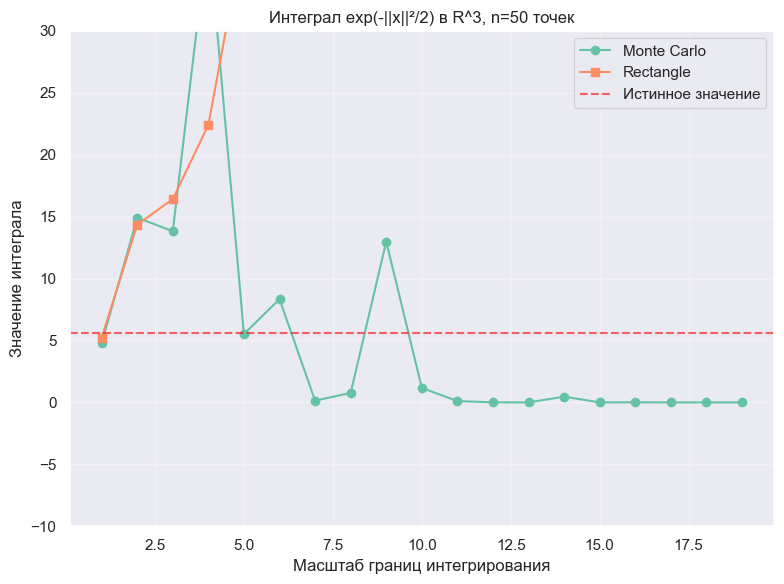

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def func(X):
    return np.exp(-0.5 * np.sum(X**2, axis=1))

n = 50
d = 3
real_val = np.power(np.pi, d / 2)  
low0, high0 = -np.ones(d), np.ones(d)

mk_res = []
rect_res = []

scale_grid = range(1, 20)  

for scale in scale_grid:
    low, high = low0 * scale, high0 * scale  
    mk_res.append(Integrator.integrate_monte_carlo(func, low, high, n))
    rect_res.append(Integrator.integrate_rectangle(func, low, high, n))

plt.figure(figsize=(8, 6))
plt.plot(scale_grid, mk_res, "o-", label="Monte Carlo")
plt.plot(scale_grid, rect_res, "s-", label="Rectangle")
plt.axhline(real_val, color="r", linestyle="--", alpha=0.6, label="Истинное значение")
plt.xlabel("Масштаб границ интегрирования")
plt.ylabel("Значение интеграла")
plt.ylim([-10, 30])
plt.title(f"Интеграл exp(-||x||²/2) в R^{d}, n={n} точек")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Вывод:** Выходит, прямоугльникик переоценивают интеграл, причём сильно, нужно менять количество точек. А МК недооценивает, потому что равновероятно берёт любые точки, как важные так и не важные